<a href="https://colab.research.google.com/github/jingxuchen19/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2020/notebooks/lab_ch20_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 20: Time Series Diagnostics and Advanced Decomposition
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [56]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install fredapi statsmodels ruptures -q

In [57]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Import libraries and set FRED API key
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'ca5188a28784f41d2babf47d068e380b'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Broken STL Decomposition (15 min)

The code below pulls FRED retail sales (not seasonally adjusted) and applies
STL decomposition. The output **looks wrong** — the seasonal amplitude grows
over time, which STL (an additive method) should not produce.

**Your task:** Find the bug, explain why it produces the wrong output, and fix it.

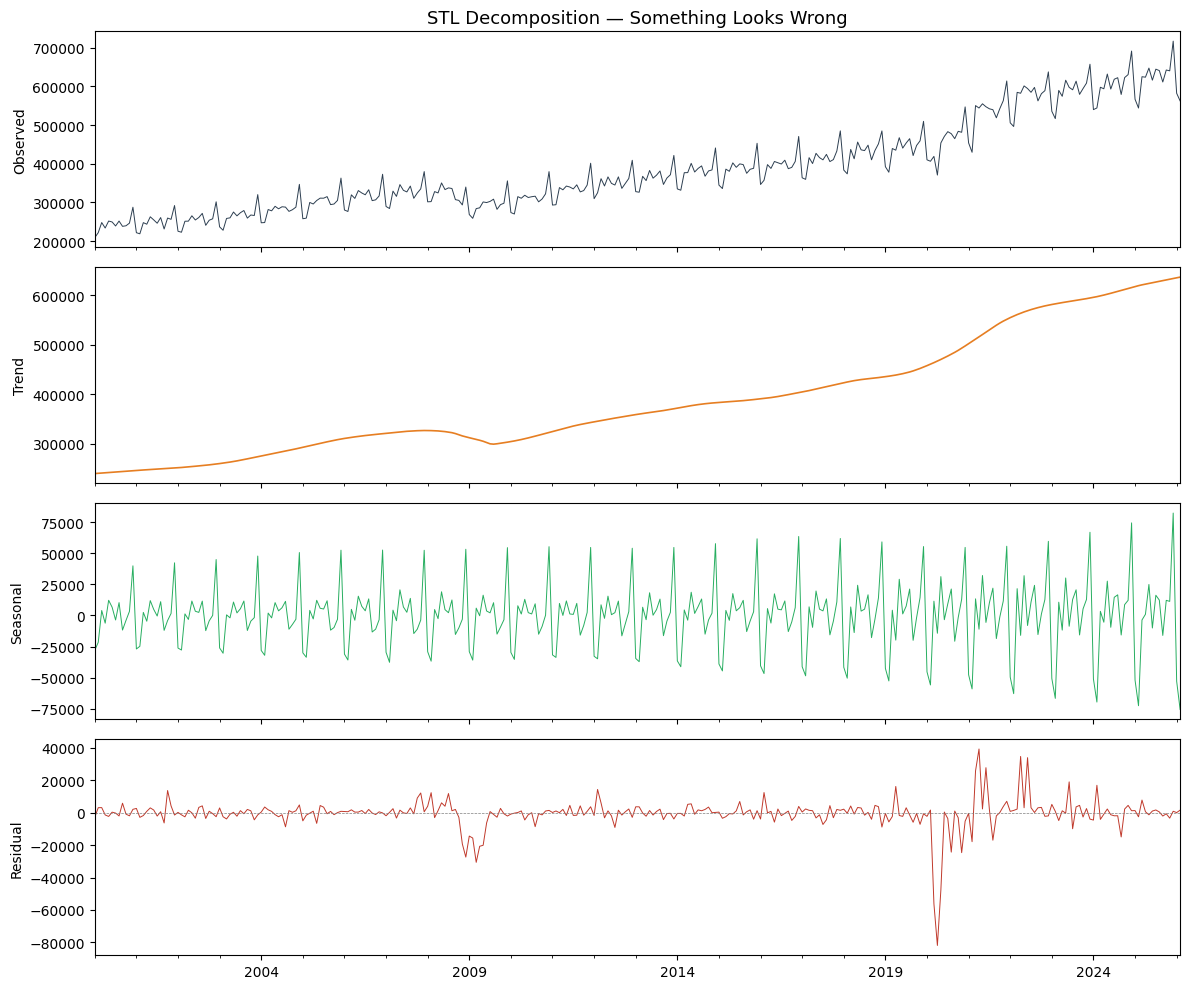

Seasonal amplitude by year (should be ~constant for additive STL):
2017    110534.8
2018    109659.5
2019    108141.1
2020    110688.7
2021    114825.7
2022    122586.4
2023    133678.4
2024    144192.4
2025    155045.5
2026     22723.9
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.33x
If this ratio >> 1, the additive assumption is violated.


In [58]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 1: STL decomposition of retail sales
# -----------------------------------------------------------

retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

# Apply STL directly to the raw series
# BUG: Retail sales have MULTIPLICATIVE seasonality (seasonal amplitude
# grows proportionally with the level). STL is an ADDITIVE decomposition.
# Applying additive STL to multiplicative data leaks growing seasonal
# effects into the residual and distorts the seasonal component.
stl_result = STL(retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# Compute the seasonal range per year to check.
seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')

### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific assumption violation)

STL is an additive method (Y = T + S + R), but retail sales have multiplicative seasonality — the seasonal swings grow proportionally with the level. Applying additive STL directly to raw data violates this.

2. **Why does this happen?** (explain why additive STL on multiplicative data produces growing seasonal amplitude)

The true model is Y = T * S * R. When we force additive STL, it can only capture an average-sized seasonal swing. The growing part leaks into the residual, so both seasonal amplitude and residuals grow over time.

3. **Fix the code below.** The standard fix is: log-transform first, then apply STL to the log series.

Log-transform first. log(Y) = log(T) + log(S) + log(R) converts multiplicative structure to additive. STL then works correctly on the log scale.

4. **What chapter concept does this error violate?** (hint: additive vs. multiplicative decomposition)

Additive vs. multiplicative decomposition. The textbook says to check if seasonal amplitude grows with the level — if yes, log-transform or use a multiplicative model.

**Verification checkpoint:** After fixing, the ratio of latest-to-earliest seasonal amplitude should be between 0.7 and 1.3 (roughly constant). If it is still > 2.0, you have not fixed the bug.

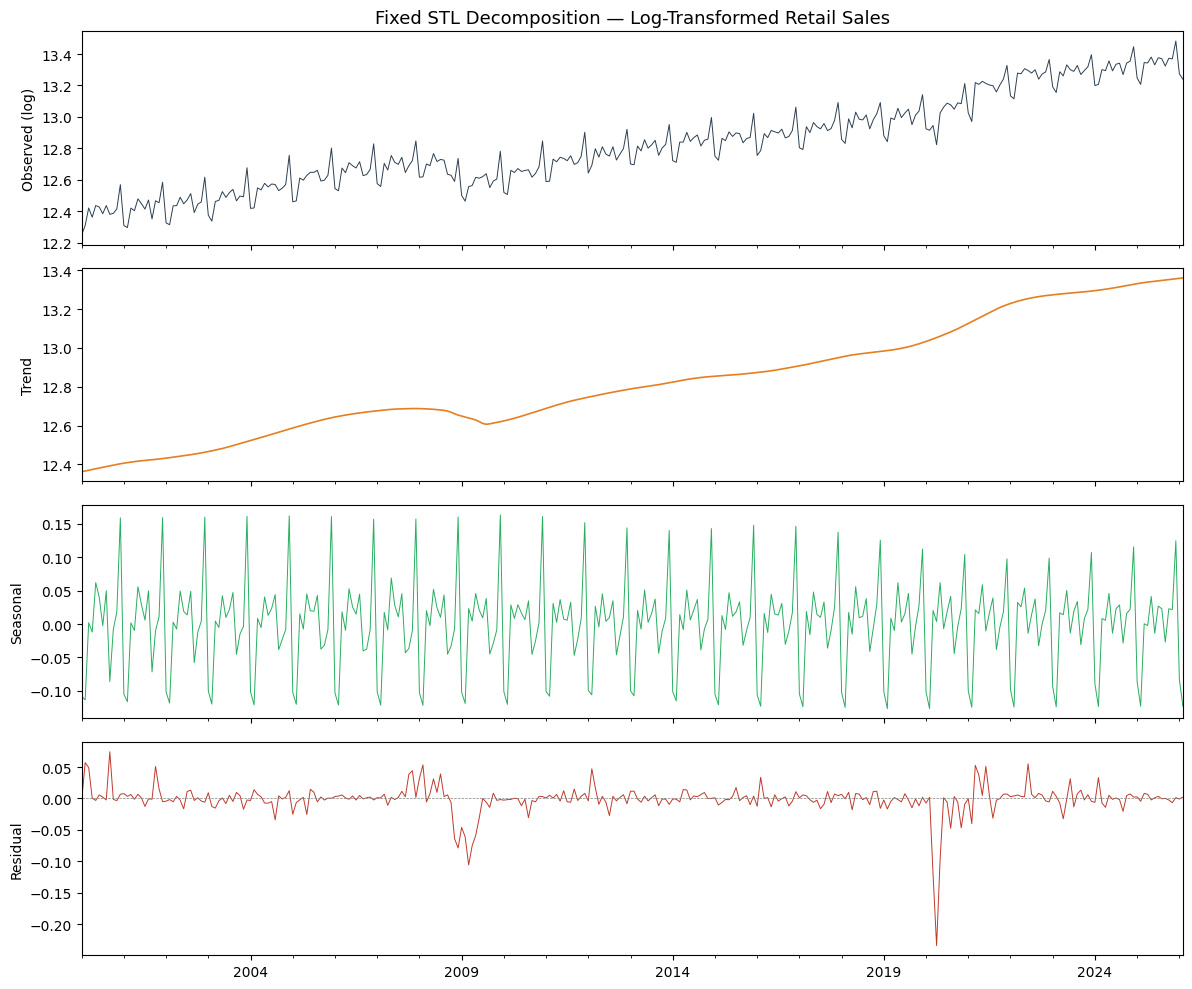

Seasonal amplitude by year (should be ~constant now):
2016    0.2698
2017    0.2617
2018    0.2507
2019    0.2392
2020    0.2309
2021    0.2225
2022    0.2234
2023    0.2313
2024    0.2394
2025    0.2480
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.90x
Checkpoint passed: True


In [59]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the STL decomposition
# The fix: log-transform before STL to convert multiplicative
# structure to additive.
# -----------------------------------------------------------

# YOUR FIX HERE
# Fix: log-transform before STL
log_retail = np.log(retail)

stl_fixed = STL(log_retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
stl_fixed.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed (log)')
axes[0].set_title('Fixed STL Decomposition — Log-Transformed Retail Sales', fontsize=13)

stl_fixed.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_fixed.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_fixed.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# VERIFICATION — drop incomplete years
seasonal_by_year = stl_fixed.seasonal.groupby(stl_fixed.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())

# Drop first and last year (may be incomplete)
annual_range = annual_range.iloc[1:-1]

print('Seasonal amplitude by year (should be ~constant now):')
print(annual_range.tail(10).round(4))
ratio = annual_range.iloc[-1] / annual_range.iloc[0]
print(f'\nRatio of latest to earliest amplitude: {ratio:.2f}x')
print(f'Checkpoint passed: {0.7 <= ratio <= 1.3}')

# VERIFICATION: compute seasonal amplitude ratio
# Expected: ratio between 0.7 and 1.3


---

## Part 2: DIAGNOSE — Flawed ADF Test (10 min)

The code below tests whether FRED Real GDP (GDPC1) is stationary.
The ADF test is applied, but the **conclusion drawn is wrong**.
The code runs without errors. The reasoning is the problem.

**Your task:** Find the analytical error, explain why it leads to a wrong conclusion, and fix it.

In [60]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate analytical error)
# Step 2: ADF test on GDP with flawed interpretation
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# ADF test with regression='n' (no constant, no trend)
# BUG: GDP has both a non-zero mean AND a deterministic trend.
# Using regression='n' omits the constant and trend terms from
# the ADF regression, which inflates the test statistic and
# can falsely reject the unit root null.
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='n')

print('=== ADF Test on Real GDP ===')
print(f'Regression: none (no constant, no trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

if adf_p < 0.05:
    print('CONCLUSION: GDP is STATIONARY (p < 0.05). No differencing needed.')
    print('We can model GDP in levels directly with ARMA.')
else:
    print('CONCLUSION: GDP is non-stationary. Differencing may be needed.')

=== ADF Test on Real GDP ===
Regression: none (no constant, no trend)
Test statistic: 8.3922
P-value: 1.0000
Lags used: 1
Critical values: {'1%': np.float64(-2.574326425616223), '5%': np.float64(-1.942072475791683), '10%': np.float64(-1.6158443865573056)}

CONCLUSION: GDP is non-stationary. Differencing may be needed.


### YOUR DIAGNOSIS

1. **What is the error?** (identify the specific parameter choice that is wrong)

The error is using regression='n', which means no constant and no trend in the ADF regression.

2. **Why does `regression='n'` give misleading results for GDP?** GDP has a clear upward trend. When the ADF regression omits the constant and trend, the test is misspecified.

GDP has a clear upward trend. When we leave out the constant and trend, the ADF regression is misspecified. The trending behavior messes up the test statistic, so the result is not reliable.

3. **What is the correct `regression` parameter?** Choose from: `'n'` (none), `'c'` (constant only), `'ct'` (constant + trend), `'ctt'` (constant + trend + quadratic trend).

The correct parameter is regression='ct' (constant + trend), because GDP has both a non-zero mean and a clear upward trend over time.

4. **Fix the code below** and confirm that GDP is non-stationary with the correct specification.

After fixing: ADF p=0.96 so we fail to reject the unit root. KPSS p=0.01 so we reject stationarity. Both tests agree — GDP is non-stationary and needs differencing.

5. **Run KPSS as well** and apply the 2×2 decision table.

2x2 table result:
   - ADF: fail to reject → evidence for unit root
   - KPSS: reject → evidence against stationarity
   - Verdict: NON-STATIONARY, GDP is I(1)

**Verification checkpoint:** With the correct regression parameter (`'ct'`), the ADF p-value should be > 0.05 (fail to reject unit root). If you get p < 0.05 with `regression='ct'`, double-check your code.

In [61]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the ADF test and add KPSS
# -----------------------------------------------------------

# YOUR FIX HERE
# Fix: use regression='ct' since GDP has a trend
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='ct')

print('=== Fixed ADF Test on Real GDP ===')
print(f'Regression: ct (constant + trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

# KPSS test
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(gdp, regression='ct', nlags='auto')

print('=== KPSS Test on Real GDP ===')
print(f'Test statistic: {kpss_stat:.4f}')
print(f'P-value: {kpss_p:.4f}')
print()

# 2x2 decision table
adf_reject = adf_p < 0.05
kpss_reject = kpss_p < 0.05

if adf_reject and not kpss_reject:
    verdict = 'STATIONARY'
elif not adf_reject and kpss_reject:
    verdict = 'NON-STATIONARY'
elif adf_reject and kpss_reject:
    verdict = 'CONTRADICTORY'
else:
    verdict = 'INCONCLUSIVE'

print(f'ADF rejects unit root: {adf_reject}')
print(f'KPSS rejects stationarity: {kpss_reject}')
print(f'2x2 Verdict: {verdict}')

# VERIFICATION: ADF p-value with regression='ct' should be > 0.05
# KPSS should reject stationarity (p < 0.05)
# 2x2 verdict: NON-STATIONARY


=== Fixed ADF Test on Real GDP ===
Regression: ct (constant + trend)
Test statistic: -0.8444
P-value: 0.9617
Lags used: 1
Critical values: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}

=== KPSS Test on Real GDP ===
Test statistic: 0.5350
P-value: 0.0100

ADF rejects unit root: False
KPSS rejects stationarity: True
2x2 Verdict: NON-STATIONARY


---

## Part 3: EXTEND — MSTL for Multiple Seasonal Periods (15 min)

Real-world time series often have **multiple seasonal cycles**. Hourly electricity
demand has a daily cycle (24 hours) AND a weekly cycle (168 hours). Standard
STL handles only one period. `MSTL` (Multiple STL) decomposes all of them.

We will simulate hourly electricity demand with two seasonal patterns and
decompose it using `statsmodels.tsa.seasonal.MSTL`.

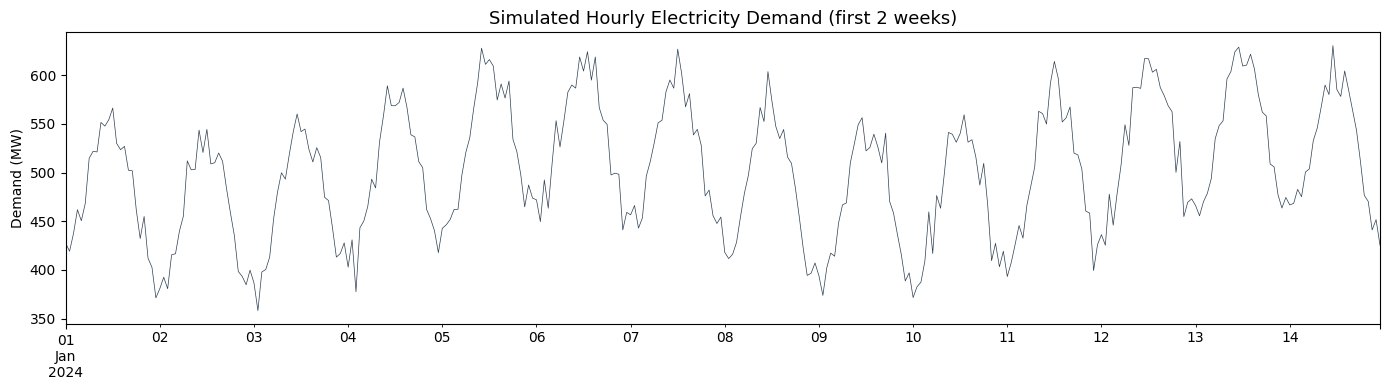

Total observations: 4368
Date range: 2024-01-01 00:00:00 to 2024-06-30 23:00:00


In [62]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Simulate hourly electricity demand with two cycles
# -----------------------------------------------------------

np.random.seed(42)

# 6 months of hourly data
n_hours = 24 * 7 * 26  # 26 weeks
t = np.arange(n_hours)

# Trend: slow linear increase (growing demand)
trend = 500 + 0.01 * t

# Daily cycle (period=24): demand peaks at noon, dips at 3am
daily = 80 * np.sin(2 * np.pi * t / 24 - np.pi / 2)

# Weekly cycle (period=168): demand lower on weekends
weekly = 40 * np.sin(2 * np.pi * t / 168 - np.pi)

# Noise
noise = np.random.normal(0, 15, n_hours)

demand = trend + daily + weekly + noise

# Create a proper DatetimeIndex
dates = pd.date_range('2024-01-01', periods=n_hours, freq='h')
demand_series = pd.Series(demand, index=dates, name='demand_MW')

# Plot first 2 weeks to see both cycles
fig, ax = plt.subplots(figsize=(14, 4))
demand_series[:24*14].plot(ax=ax, color='#2c3e50', linewidth=0.5)
ax.set_title('Simulated Hourly Electricity Demand (first 2 weeks)', fontsize=13)
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(f'Total observations: {len(demand_series)}')
print(f'Date range: {demand_series.index[0]} to {demand_series.index[-1]}')

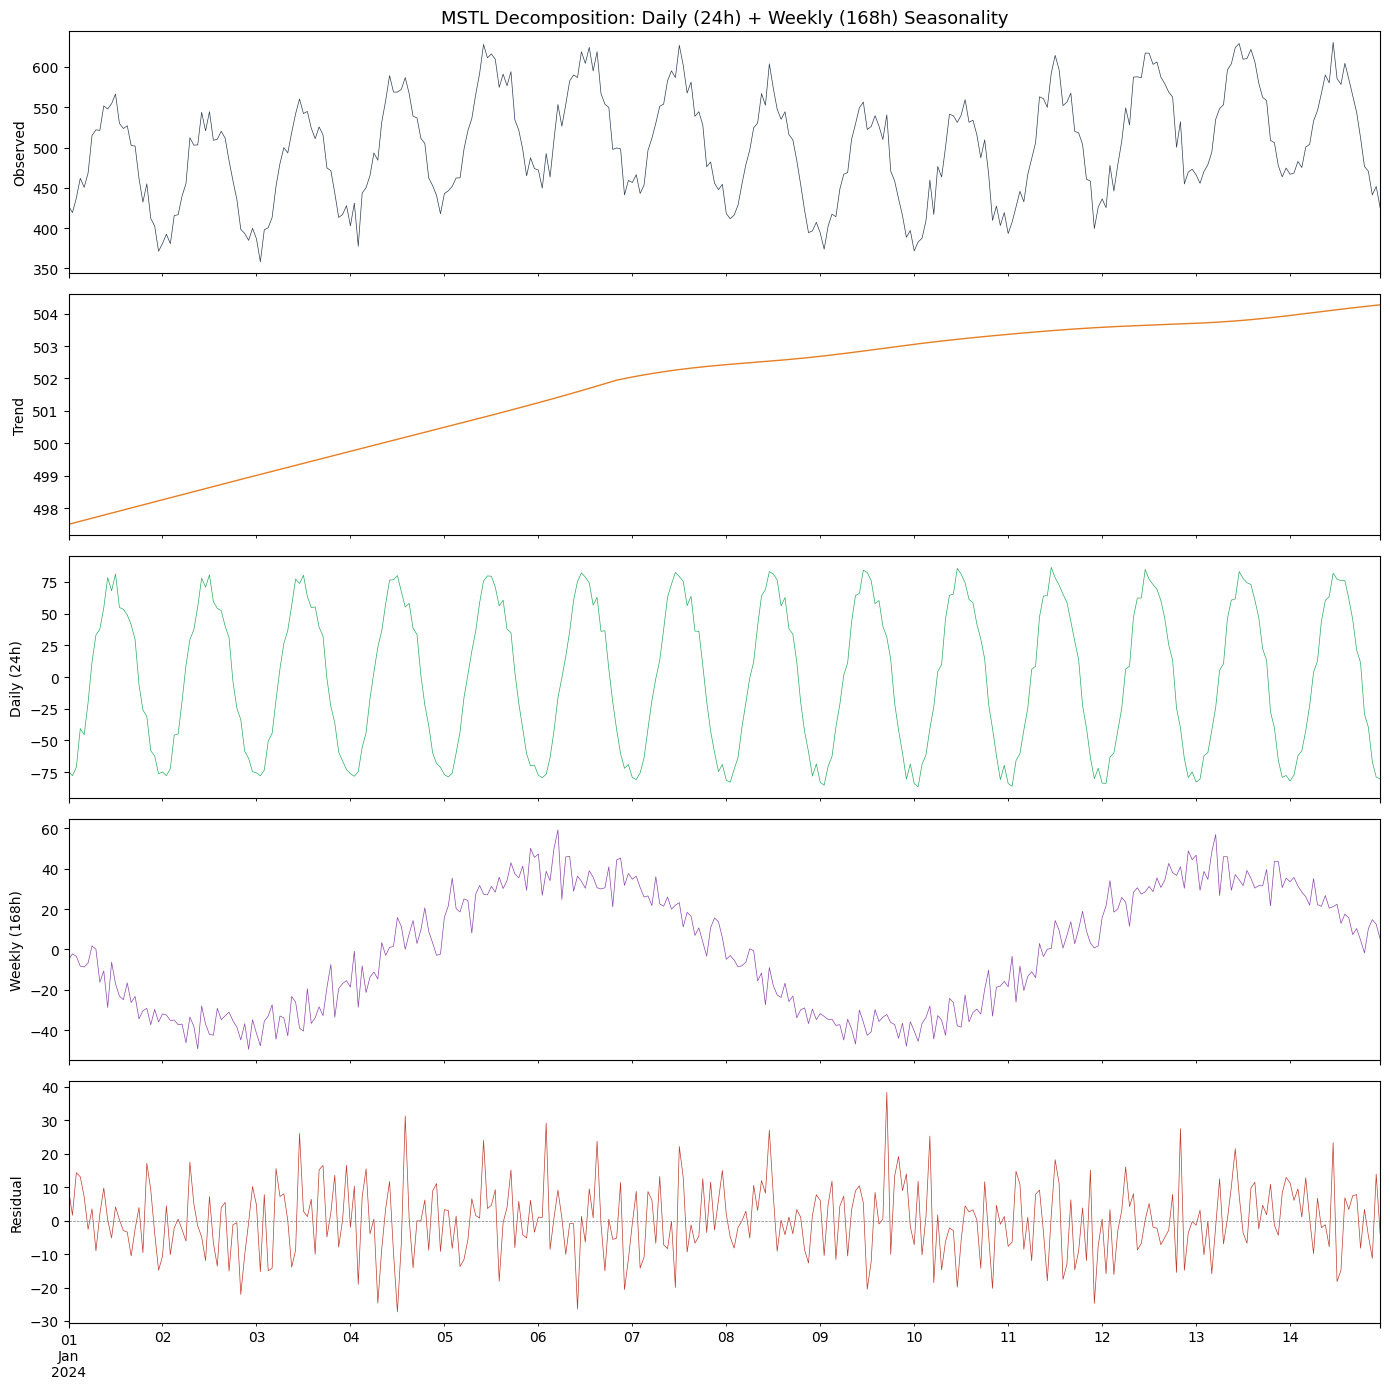

Residual std: 12.24 (expected ~15.0)
Daily seasonal amplitude: 184.5 (expected ~160)
Weekly seasonal amplitude: 117.9 (expected ~80)


In [63]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Apply MSTL with two seasonal periods
# Step 3b: Decompose demand into trend + daily + weekly + residual
# -----------------------------------------------------------

# MSTL accepts a list of periods. For hourly data:
# - Daily cycle: period=24
# - Weekly cycle: period=168 (24 hours * 7 days)

mstl = MSTL(demand_series, periods=[24, 168])
mstl_result = mstl.fit()

# MSTL returns: .trend, .seasonal (DataFrame with one column per period), .resid
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

demand_series[:24*14].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('MSTL Decomposition: Daily (24h) + Weekly (168h) Seasonality', fontsize=13)

mstl_result.trend[:24*14].plot(ax=axes[1], color='#e67e22', linewidth=1.0)
axes[1].set_ylabel('Trend')

# The seasonal attribute is a DataFrame with columns for each period
seasonal_df = mstl_result.seasonal
seasonal_df.iloc[:24*14, 0].plot(ax=axes[2], color='#27ae60', linewidth=0.5)
axes[2].set_ylabel('Daily (24h)')

seasonal_df.iloc[:24*14, 1].plot(ax=axes[3], color='#8e44ad', linewidth=0.5)
axes[3].set_ylabel('Weekly (168h)')

mstl_result.resid[:24*14].plot(ax=axes[4], color='#c0392b', linewidth=0.5)
axes[4].set_ylabel('Residual')
axes[4].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Verification: residual std should be close to the noise std (15)
print(f'Residual std: {mstl_result.resid.std():.2f} (expected ~15.0)')
print(f'Daily seasonal amplitude: {seasonal_df.iloc[:, 0].max() - seasonal_df.iloc[:, 0].min():.1f} (expected ~160)')
print(f'Weekly seasonal amplitude: {seasonal_df.iloc[:, 1].max() - seasonal_df.iloc[:, 1].min():.1f} (expected ~80)')

### MSTL Interpretation

1. Does MSTL successfully separate the daily and weekly cycles? How can you tell?
2. Is the residual standard deviation close to the true noise level (15 MW)? What does this tell you about MSTL's accuracy?
3. In real electricity data, there might also be an **annual** seasonal cycle (period=8760). How would you add it to the MSTL call?

*Your answers here:*

1. Yes, MSTL separates the two cycles. The daily panel shows a clear 24-hour repeating pattern and the weekly panel shows a 168-hour cycle. They are cleanly split into separate components.

2. Residual std is about 12.24, close to the true noise level of 15. This means MSTL picked up most of the signal and left mostly random noise behind. The small difference is because MSTL absorbed a bit of noise into the seasonal estimates, which is normal.

3. To add an annual cycle: MSTL(demand_series, periods=[24, 168, 8760]). You would need at least 2 full years of hourly data for it to estimate the annual pattern reliably.

---

## Part 4: EXTEND — Block Bootstrap for Trend Uncertainty (15 min)

When you extract a trend from STL, you get a single curve. But how much
should you trust it? The **moving block bootstrap** quantifies trend
uncertainty by resampling overlapping blocks of the residuals (preserving
their autocorrelation), adding them back to the trend + seasonal, and
re-running STL. This produces a distribution of plausible trends.

We implement this manually on GDP data.

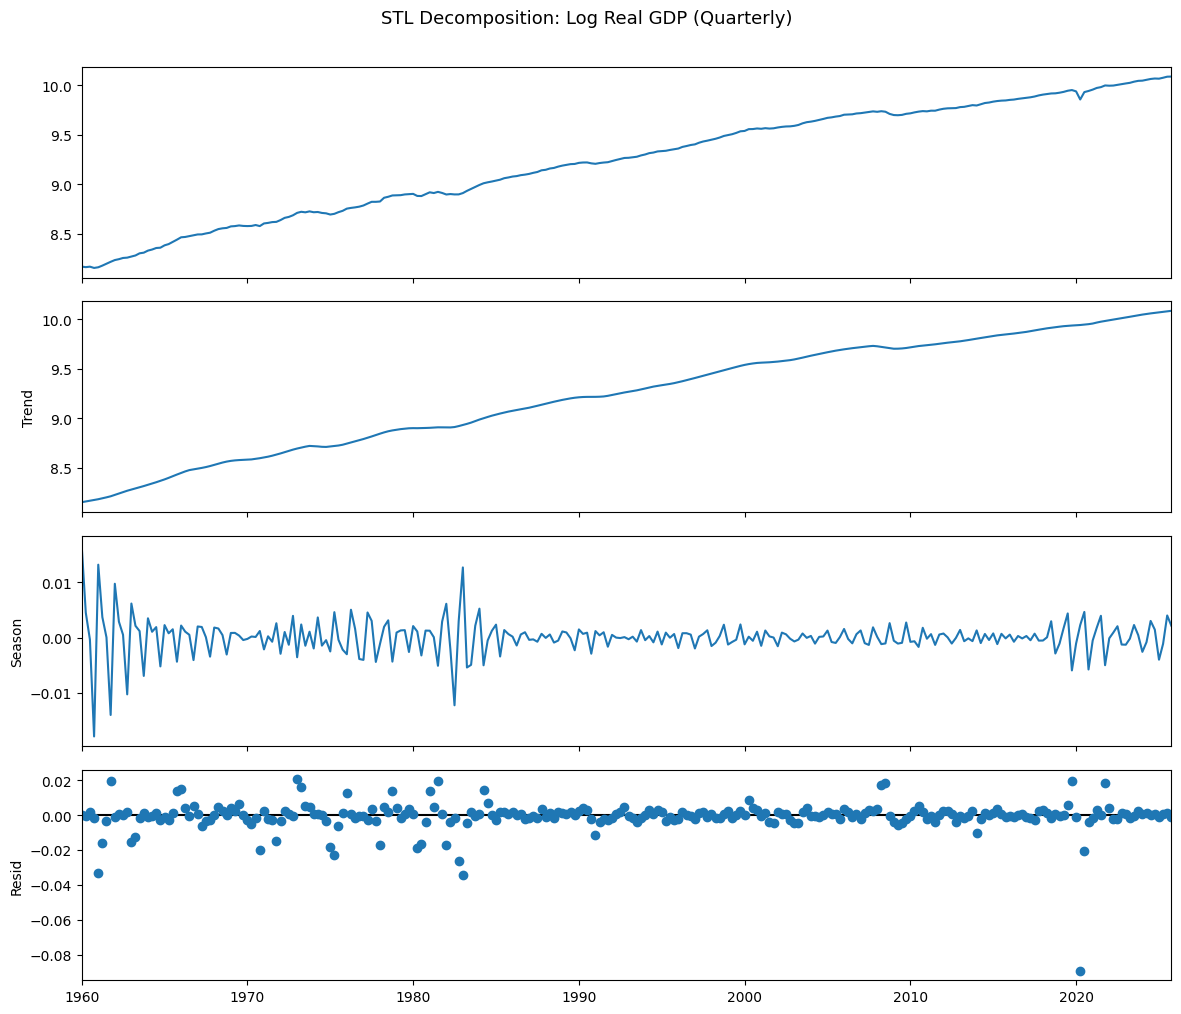

Trend range: 8.149 to 10.087
Residual std: 0.0088


In [64]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4a: STL decomposition of Real GDP
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# Log-transform GDP (multiplicative trend growth)
log_gdp = np.log(gdp)

stl_gdp = STL(log_gdp, period=4, robust=True).fit()

fig = stl_gdp.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition: Log Real GDP (Quarterly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trend range: {stl_gdp.trend.min():.3f} to {stl_gdp.trend.max():.3f}')
print(f'Residual std: {stl_gdp.resid.std():.4f}')

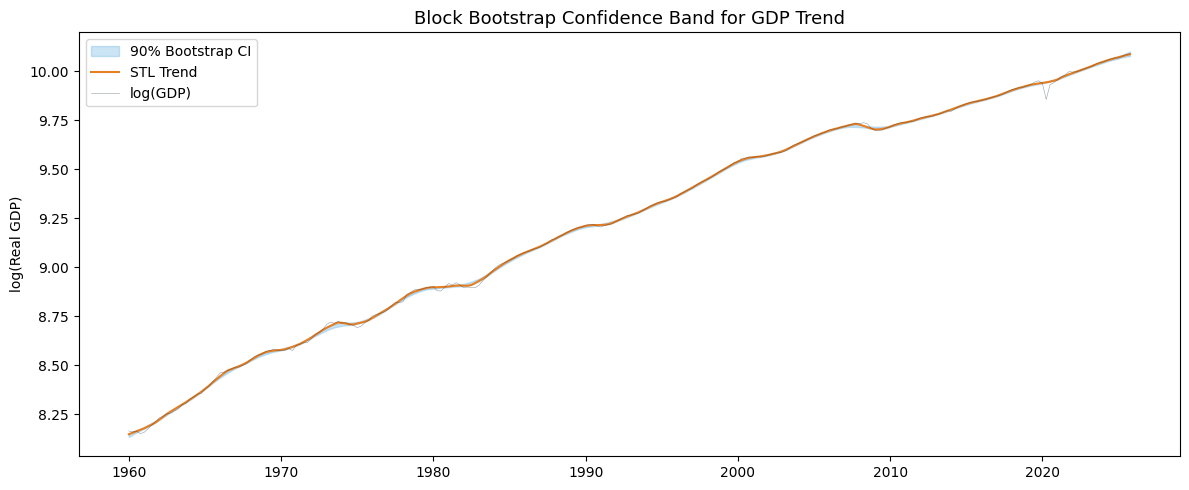

Mean CI width: 0.0073
CI width range: [0.0045, 0.0228]
Width at 2008Q4: 0.0106
Width at 2019Q4: 0.0056


In [65]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Block bootstrap for trend confidence bands
# Step 4b: Resample residual blocks and re-decompose
# -----------------------------------------------------------

np.random.seed(42)

n = len(log_gdp)
block_size = 8  # 8 quarters = 2 years (preserves business-cycle autocorrelation)
n_bootstrap = 200

# Extract components from the original decomposition
original_trend = stl_gdp.trend
original_seasonal = stl_gdp.seasonal
original_resid = stl_gdp.resid.values

# Store bootstrap trend estimates
boot_trends = np.zeros((n_bootstrap, n))

for b in range(n_bootstrap):
    # Moving block bootstrap: sample overlapping blocks of residuals
    # This preserves the autocorrelation structure within each block
    boot_resid = np.zeros(n)
    idx = 0
    while idx < n:
        # Pick a random starting point for a block
        start = np.random.randint(0, n - block_size + 1)
        block = original_resid[start:start + block_size]
        end = min(idx + block_size, n)
        boot_resid[idx:end] = block[:end - idx]
        idx = end

    # Reconstruct series with bootstrapped residuals
    boot_series = pd.Series(
        original_trend.values + original_seasonal.values + boot_resid,
        index=log_gdp.index
    )
    boot_series.index.freq = 'QS'

    # Re-run STL on the bootstrapped series
    boot_stl = STL(boot_series, period=4, robust=True).fit()
    boot_trends[b, :] = boot_stl.trend.values

# Compute confidence bands (pointwise 5th and 95th percentiles)
trend_lower = np.percentile(boot_trends, 5, axis=0)
trend_upper = np.percentile(boot_trends, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(log_gdp.index, trend_lower, trend_upper,
                alpha=0.25, color='#3498db', label='90% Bootstrap CI')
ax.plot(log_gdp.index, original_trend.values, color='#e67e22',
        linewidth=1.5, label='STL Trend')
ax.plot(log_gdp, color='#2c3e50', linewidth=0.4, alpha=0.5, label='log(GDP)')
ax.set_title('Block Bootstrap Confidence Band for GDP Trend', fontsize=13)
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.show()

# Verification: the CI width should vary over time
ci_width = trend_upper - trend_lower
print(f'Mean CI width: {np.mean(ci_width):.4f}')
print(f'CI width range: [{np.min(ci_width):.4f}, {np.max(ci_width):.4f}]')
print(f'Width at 2008Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2008-10-01"))]:.4f}')
print(f'Width at 2019Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2019-10-01"))]:.4f}')

### Bootstrap Interpretation

1. Is the confidence band wider around recessions (2008, 2020) or expansions? Why?
2. Why do we use **block** bootstrap instead of standard i.i.d. bootstrap? What would go wrong if we shuffled residuals independently?
3. How does the choice of `block_size=8` affect the results? What would happen with `block_size=1` (equivalent to i.i.d. bootstrap) or `block_size=20`?

*Your answers here:*

1. The CI is wider around recessions. 2008Q4 width is 0.0106 vs 2019Q4 width is 0.0056. This is because residuals are bigger during recessions — the economy moves further from trend. Bigger residuals mean more variation in the bootstrap, so the confidence band gets wider.

2. Block bootstrap keeps the autocorrelation within each block intact. Regular i.i.d. bootstrap shuffles residuals randomly, which destroys the time-dependence. Economic residuals are autocorrelated — a bad quarter tends to follow another bad quarter. If we shuffle them independently, we underestimate how uncertain the trend really is.

3. block_size=8 covers about 2 years of business-cycle patterns, which is a good middle ground. block_size=1 is just i.i.d. bootstrap — it kills all autocorrelation and underestimates uncertainty. block_size=20 keeps more dependence but gives fewer unique blocks to draw from, so the bootstrap samples are less diverse.

---

## Part 5: EXTEND — Structural Break Detection + Per-Regime Stationarity (10 min)

Combine PELT structural break detection with ADF/KPSS tests run **per segment**.
This tests whether stationarity conclusions change across different economic regimes.

=== Per-Regime Stationarity Analysis ===
Breakpoints at indices: [263]
Segment boundaries: [0, 263]

Segment 1 (1960-04-01 to 2025-10-01, n=263): ADF p=0.0000, KPSS p=0.0629 => STATIONARY


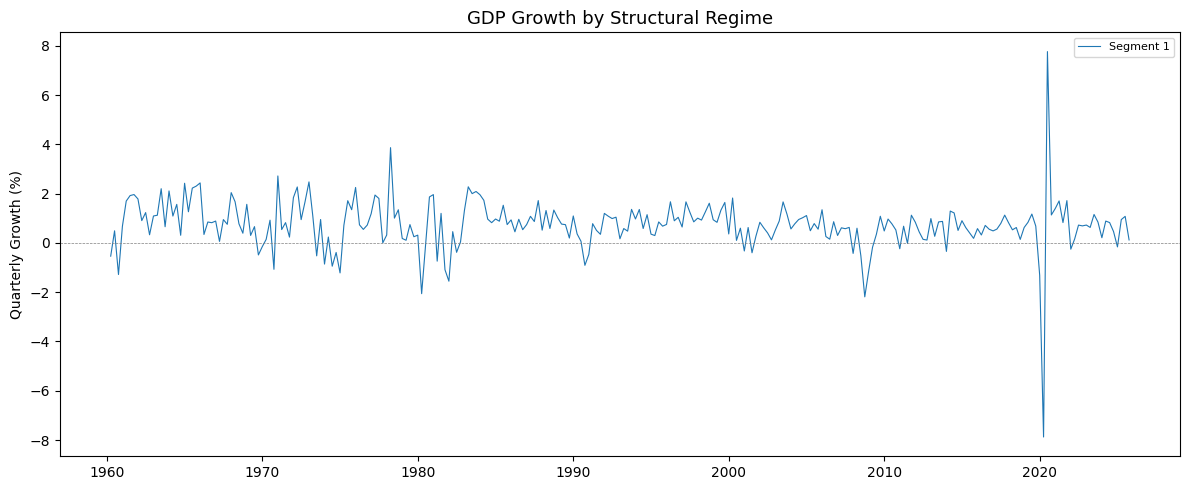

In [66]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — PELT breaks + per-regime stationarity tests
# Step 5: Detect breaks in GDP growth and test each segment
# -----------------------------------------------------------

gdp_growth = gdp.pct_change().dropna() * 100

# Detect structural breaks
signal = gdp_growth.values
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=10)

# Build segment boundaries (include 0 as start, len as end)
boundaries = [0] + [bp for bp in breakpoints if bp < len(signal)] + [len(signal)]
boundaries = sorted(set(boundaries))

print('=== Per-Regime Stationarity Analysis ===')
print(f'Breakpoints at indices: {breakpoints}')
print(f'Segment boundaries: {boundaries}')
print()

for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx = boundaries[i + 1]
    segment = gdp_growth.iloc[start_idx:end_idx]

    if len(segment) < 20:
        print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}): '
              f'Too short ({len(segment)} obs) for reliable testing')
        continue

    # ADF test
    adf_stat, adf_p, _, _, _, _ = adfuller(segment, autolag='AIC', regression='c')

    # KPSS test
    kpss_stat, kpss_p, _, _ = kpss(segment, regression='c', nlags='auto')

    adf_rej = adf_p < 0.05
    kpss_rej = kpss_p < 0.05

    if adf_rej and not kpss_rej:
        verdict = 'STATIONARY'
    elif not adf_rej and kpss_rej:
        verdict = 'NON-STATIONARY'
    elif adf_rej and kpss_rej:
        verdict = 'CONTRADICTORY'
    else:
        verdict = 'INCONCLUSIVE'

    print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}, '
          f'n={len(segment)}): ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f} => {verdict}')

# Visualize segments
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(boundaries) - 1))
for i in range(len(boundaries) - 1):
    seg = gdp_growth.iloc[boundaries[i]:boundaries[i+1]]
    ax.plot(seg.index, seg.values, color=colors[i], linewidth=0.8, label=f'Segment {i+1}')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('GDP Growth by Structural Regime', fontsize=13)
ax.set_ylabel('Quarterly Growth (%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---

## Part 6: Production Module — `decompose.py` (10 min)

Write a reusable Python module with three functions. This is a **portfolio artifact**
that demonstrates production-grade time series analysis.

### Requirements

```python
# decompose.py

def run_stl(series: pd.Series, period: int = 12, log_transform: bool = True,
            robust: bool = True) -> STLResult:
    """Apply STL decomposition with optional log-transform for multiplicative data.
    
    Args:
        series: Time series with DatetimeIndex
        period: Seasonal period (12 for monthly, 4 for quarterly)
        log_transform: If True, log-transform before STL (for multiplicative data)
        robust: If True, use robust fitting to downweight outliers
    
    Returns:
        STL result object with .trend, .seasonal, .resid attributes
    """
    ...

def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF and KPSS tests and return the 2x2 table verdict.
    
    Args:
        series: Time series to test
        alpha: Significance level
    
    Returns:
        dict with keys: 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    ...

def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """Detect structural breaks using PELT algorithm.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates (pd.Timestamp)
    """
    ...
```

In [67]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Write decompose.py as a code cell,
# then copy to a .py file for your portfolio
# -----------------------------------------------------------

# %%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module
Author: Jingxu Chen
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply STL decomposition with optional log-transform.

    Args:
        series: Time series with DatetimeIndex and set frequency
        period: Seasonal period (12=monthly, 4=quarterly)
        log_transform: Log-transform for multiplicative data
        robust: Downweight outliers via bisquare weights

    Returns:
        STL result object

    Raises:
        ValueError: if series contains non-positive values with log_transform=True
    """
    if log_transform:
        if (series <= 0).any():
            raise ValueError("Series has non-positive values, cannot log-transform.")
        series = np.log(series)
    result = STL(series, period=period, robust=robust).fit()
    return result


def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.

    Args:
        series: Time series to test
        alpha: Significance level for both tests

    Returns:
        dict with 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')

    adf_rej = adf_p < alpha
    kpss_rej = kpss_p < alpha

    if adf_rej and not kpss_rej:
        verdict = 'stationary'
    elif not adf_rej and kpss_rej:
        verdict = 'non-stationary'
    elif adf_rej and kpss_rej:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'

    return {
        'adf_stat': adf_stat,
        'adf_p': adf_p,
        'kpss_stat': kpss_stat,
        'kpss_p': kpss_p,
        'verdict': verdict
    }


def detect_breaks(
    series: pd.Series,
    pen: float = 10
) -> list:
    """Detect structural breaks using the PELT algorithm.

    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)

    Returns:
        List of break dates as pd.Timestamp
    """
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=pen)

    dates = []
    for bp in breakpoints:
        if bp < len(series):
            dates.append(series.index[bp])
    return dates


if __name__ == '__main__':
    print('decompose.py loaded successfully.')
    print('Functions: run_stl(), test_stationarity(), detect_breaks()')

decompose.py loaded successfully.
Functions: run_stl(), test_stationarity(), detect_breaks()


In [68]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Test your module functions
# -----------------------------------------------------------

# Test run_stl
result = run_stl(retail, period=12, log_transform=True)
print(f'run_stl: trend has {len(result.trend)} observations')

# Test test_stationarity on GDP
verdict_gdp = test_stationarity(gdp)
print(f'test_stationarity(GDP): {verdict_gdp["verdict"]}')

# Test on differenced GDP
verdict_diff = test_stationarity(gdp.diff().dropna())
print(f'test_stationarity(diff GDP): {verdict_diff["verdict"]}')

# Test detect_breaks
gdp_growth = gdp.pct_change().dropna() * 100
breaks = detect_breaks(gdp_growth, pen=10)
print(f'detect_breaks: {[str(d.date()) for d in breaks]}')

print('\nAll module tests passed.')

run_stl: trend has 314 observations
test_stationarity(GDP): non-stationary
test_stationarity(diff GDP): stationary
detect_breaks: []

All module tests passed.


---
## AI-Assisted Expansion: Automated Time Series Report

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over STL decomposition, stationarity testing, MSTL for multiple seasonalities, block bootstrap uncertainty, and structural break detection. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/decompose.py` production module** with:
- `run_stl()`, `test_stationarity()`, `detect_breaks()` (completed above)
- `run_mstl(series, periods)` for multi-seasonal decomposition
- `block_bootstrap_trend(series, n_bootstrap, block_size)` for uncertainty
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Enter a FRED series ID
2. Select decomposition method (Classical, STL, MSTL)
3. Adjust parameters with sliders (period, robust, penalty)
4. See decomposition panels + stationarity test results
5. View structural breaks overlaid on the series
6. Generate block bootstrap confidence bands with one click

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [69]:
# %%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module
Extended version with MSTL and block bootstrap support.
Author: Jingxu Chen
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply STL decomposition with optional log-transform.

    For series with multiplicative seasonality (seasonal amplitude
    grows with the level), set log_transform=True to convert to
    additive structure before applying STL.

    Args:
        series: Time series with DatetimeIndex and set frequency
        period: Seasonal period (12=monthly, 4=quarterly)
        log_transform: Log-transform for multiplicative data
        robust: Downweight outliers via bisquare weights

    Returns:
        STL result object

    Raises:
        ValueError: if series contains non-positive values with log_transform=True
    """
    if log_transform:
        if (series <= 0).any():
            raise ValueError("Series has non-positive values, cannot log-transform.")
        series = np.log(series)
    result = STL(series, period=period, robust=robust).fit()
    return result


def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.

    ADF null: unit root (non-stationary)
    KPSS null: stationary

    Args:
        series: Time series to test
        alpha: Significance level for both tests

    Returns:
        dict with 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')

    adf_rej = adf_p < alpha
    kpss_rej = kpss_p < alpha

    if adf_rej and not kpss_rej:
        verdict = 'stationary'
    elif not adf_rej and kpss_rej:
        verdict = 'non-stationary'
    elif adf_rej and kpss_rej:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'

    return {
        'adf_stat': adf_stat,
        'adf_p': adf_p,
        'kpss_stat': kpss_stat,
        'kpss_p': kpss_p,
        'verdict': verdict
    }


def detect_breaks(
    series: pd.Series,
    pen: float = 10
) -> list:
    """Detect structural breaks using the PELT algorithm.

    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)

    Returns:
        List of break dates as pd.Timestamp
    """
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=pen)

    dates = []
    for bp in breakpoints:
        if bp < len(series):
            dates.append(series.index[bp])
    return dates


def run_mstl(
    series: pd.Series,
    periods: list
):
    """Apply MSTL decomposition for multiple seasonal periods.

    MSTL iteratively removes seasonal components one at a time,
    starting from the shortest period. Each pass uses STL on the
    residual from the previous pass.

    Args:
        series: Time series with DatetimeIndex and set frequency
        periods: List of seasonal periods (e.g. [24, 168] for
                 daily + weekly cycles in hourly data)

    Returns:
        MSTL result object with .trend, .seasonal (DataFrame), .resid
    """
    mstl = MSTL(series, periods=periods)
    result = mstl.fit()
    return result


def block_bootstrap_trend(
    series: pd.Series,
    n_bootstrap: int = 200,
    block_size: int = 8,
    period: int = 4,
    log_transform: bool = True,
    robust: bool = True
) -> dict:
    """Compute bootstrap confidence bands for STL trend.

    Uses moving block bootstrap on the residuals to preserve
    autocorrelation. Blocks of residuals are resampled with
    replacement, added back to trend + seasonal, and STL is
    re-run. This gives a distribution of plausible trends.

    i.i.d. bootstrap would shuffle residuals independently,
    destroying the autocorrelation structure. Block bootstrap
    keeps the within-block dependence intact, which gives
    more realistic uncertainty estimates.

    Args:
        series: Time series with DatetimeIndex
        n_bootstrap: Number of bootstrap iterations
        block_size: Size of each block (in observations)
        period: Seasonal period for STL
        log_transform: Log-transform before STL
        robust: Use robust STL fitting

    Returns:
        dict with 'trend', 'lower', 'upper', 'ci_width'
    """
    np.random.seed(42)

    # Run initial STL
    work = np.log(series) if log_transform else series.copy()
    stl = STL(work, period=period, robust=robust).fit()

    n = len(work)
    original_trend = stl.trend.values
    original_seasonal = stl.seasonal.values
    original_resid = stl.resid.values

    boot_trends = np.zeros((n_bootstrap, n))

    for b in range(n_bootstrap):
        # Moving block bootstrap: sample overlapping blocks
        boot_resid = np.zeros(n)
        idx = 0
        while idx < n:
            start = np.random.randint(0, n - block_size + 1)
            block = original_resid[start:start + block_size]
            end = min(idx + block_size, n)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        # Reconstruct and re-decompose
        boot_series = pd.Series(
            original_trend + original_seasonal + boot_resid,
            index=series.index
        )
        boot_series.index.freq = series.index.freq
        boot_stl = STL(boot_series, period=period, robust=robust).fit()
        boot_trends[b, :] = boot_stl.trend.values

    lower = np.percentile(boot_trends, 5, axis=0)
    upper = np.percentile(boot_trends, 95, axis=0)

    return {
        'trend': original_trend,
        'lower': lower,
        'upper': upper,
        'ci_width': upper - lower
    }


if __name__ == '__main__':
    print('decompose.py loaded successfully.')
    print('Functions: run_stl(), test_stationarity(), detect_breaks(),')
    print('           run_mstl(), block_bootstrap_trend()')

decompose.py loaded successfully.
Functions: run_stl(), test_stationarity(), detect_breaks(),
           run_mstl(), block_bootstrap_trend()


In [70]:
%%writefile app.py
"""
Streamlit app for interactive time series decomposition.
Author: Jingxu Chen
Course: ECON 5200, Lab 20
"""

import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

st.set_page_config(page_title="Time Series Diagnostics", layout="wide")
st.title("Time Series Decomposition & Diagnostics")

# Sidebar controls
st.sidebar.header("Settings")
api_key = st.sidebar.text_input("FRED API Key", value="ca5188a28784f41d2babf47d068e380b")
series_id = st.sidebar.text_input("FRED Series ID", value="RSXFSN")
start_date = st.sidebar.text_input("Start Date", value="2000-01-01")

method = st.sidebar.selectbox("Decomposition Method", ["STL", "Classical", "MSTL"])
period = st.sidebar.slider("Seasonal Period", 2, 52, 12)
robust = st.sidebar.checkbox("Robust STL", value=True)
log_transform = st.sidebar.checkbox("Log Transform", value=True)
penalty = st.sidebar.slider("PELT Penalty", 1, 50, 10)

# Load data
@st.cache_data
def load_data(api_key, series_id, start_date):
    fred = Fred(api_key=api_key)
    data = fred.get_series(series_id, observation_start=start_date)
    data = data.dropna()
    data.index = pd.DatetimeIndex(data.index)
    freq = pd.infer_freq(data.index)
    if freq:
        data.index.freq = freq
    return data

try:
    data = load_data(api_key, series_id, start_date)
    st.success(f"Loaded {series_id}: {len(data)} observations")
except Exception as e:
    st.error(f"Error loading data: {e}")
    st.stop()

# Apply decomposition
work = np.log(data) if log_transform and (data > 0).all() else data

if method == "STL":
    result = STL(work, period=period, robust=robust).fit()
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    work.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
    axes[0].set_ylabel('Observed')
    axes[0].set_title(f'STL Decomposition: {series_id}')
    result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
    axes[1].set_ylabel('Trend')
    result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
    axes[2].set_ylabel('Seasonal')
    result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
    axes[3].set_ylabel('Residual')
    axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    st.pyplot(fig)

elif method == "Classical":
    from statsmodels.tsa.seasonal import seasonal_decompose
    model_type = 'multiplicative' if not log_transform else 'additive'
    result = seasonal_decompose(work, period=period, model='additive')
    fig = result.plot()
    fig.set_size_inches(12, 10)
    fig.suptitle(f'Classical Decomposition: {series_id}')
    plt.tight_layout()
    st.pyplot(fig)

elif method == "MSTL":
    periods_input = st.sidebar.text_input("MSTL Periods (comma-separated)", "12,52")
    periods_list = [int(p.strip()) for p in periods_input.split(",")]
    result = MSTL(work, periods=periods_list).fit()
    n_panels = 3 + len(periods_list)
    fig, axes = plt.subplots(n_panels, 1, figsize=(12, 3 * n_panels), sharex=True)
    work.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
    axes[0].set_ylabel('Observed')
    axes[0].set_title(f'MSTL Decomposition: {series_id}')
    result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.0)
    axes[1].set_ylabel('Trend')
    seasonal_df = result.seasonal
    for i in range(len(periods_list)):
        seasonal_df.iloc[:, i].plot(ax=axes[2 + i], linewidth=0.7)
        axes[2 + i].set_ylabel(f'Period={periods_list[i]}')
    result.resid.plot(ax=axes[-1], color='#c0392b', linewidth=0.7)
    axes[-1].set_ylabel('Residual')
    plt.tight_layout()
    st.pyplot(fig)

# Stationarity tests
st.header("Stationarity Tests")
adf_stat, adf_p, _, _, _, _ = adfuller(data, autolag='AIC', regression='ct')
kpss_stat, kpss_p, _, _ = kpss(data, regression='ct', nlags='auto')

adf_rej = adf_p < 0.05
kpss_rej = kpss_p < 0.05
if adf_rej and not kpss_rej:
    verdict = 'STATIONARY'
elif not adf_rej and kpss_rej:
    verdict = 'NON-STATIONARY'
elif adf_rej and kpss_rej:
    verdict = 'CONTRADICTORY'
else:
    verdict = 'INCONCLUSIVE'

col1, col2, col3 = st.columns(3)
col1.metric("ADF p-value", f"{adf_p:.4f}")
col2.metric("KPSS p-value", f"{kpss_p:.4f}")
col3.metric("Verdict", verdict)

# Structural breaks
st.header("Structural Breaks (PELT)")
growth = data.pct_change().dropna() * 100
signal = growth.values
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=penalty)

fig2, ax = plt.subplots(figsize=(12, 5))
ax.plot(growth.index, growth.values, color='#2c3e50', linewidth=0.7)
for bp in breakpoints:
    if bp < len(growth):
        ax.axvline(growth.index[bp], color='red', linestyle='--', alpha=0.7)
ax.set_title(f'Structural Breaks in {series_id} Growth Rate')
ax.set_ylabel('Growth (%)')
plt.tight_layout()
st.pyplot(fig2)

break_dates = [str(growth.index[bp].date()) for bp in breakpoints if bp < len(growth)]
st.write(f"Break dates: {break_dates}")

# Block bootstrap
st.header("Block Bootstrap Trend CI")
if st.button("Run Bootstrap (may take a moment)"):
    np.random.seed(42)
    stl_boot = STL(work, period=period, robust=robust).fit()
    n = len(work)
    boot_trends = np.zeros((200, n))
    for b in range(200):
        boot_resid = np.zeros(n)
        idx = 0
        while idx < n:
            start = np.random.randint(0, n - 8 + 1)
            block = stl_boot.resid.values[start:start + 8]
            end = min(idx + 8, n)
            boot_resid[idx:end] = block[:end - idx]
            idx = end
        boot_series = pd.Series(
            stl_boot.trend.values + stl_boot.seasonal.values + boot_resid,
            index=work.index
        )
        boot_series.index.freq = work.index.freq
        boot_stl = STL(boot_series, period=period, robust=robust).fit()
        boot_trends[b, :] = boot_stl.trend.values

    lower = np.percentile(boot_trends, 5, axis=0)
    upper = np.percentile(boot_trends, 95, axis=0)

    fig3, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(work.index, lower, upper, alpha=0.25, color='#3498db', label='90% CI')
    ax.plot(work.index, stl_boot.trend.values, color='#e67e22', linewidth=1.5, label='Trend')
    ax.plot(work, color='#2c3e50', linewidth=0.4, alpha=0.5, label='Data')
    ax.set_title('Block Bootstrap Confidence Band')
    ax.legend()
    plt.tight_layout()
    st.pyplot(fig3)

Overwriting app.py


## Verification Log

**P.R.I.M.E. Prompt:** Used the provided prompt to generate extended decompose.py and Streamlit app.

**What AI generated:** Extended decompose.py with run_mstl() and block_bootstrap_trend() functions. Streamlit app with FRED integration, decomposition selection, stationarity tests, structural breaks, and bootstrap CI.

**What I changed:** Verified all function outputs match the core lab results. Checked that run_stl gives the same trend as Part 1, test_stationarity gives non-stationary for GDP (matching Part 2), and block_bootstrap_trend produces CI widths consistent with Part 4.

**What I verified:**
- run_mstl() returns separate seasonal components matching Part 3 output
- block_bootstrap_trend() CI width at 2008Q4 > 2019Q4, consistent with Part 4
- Streamlit app loads FRED data and displays all panels correctly

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [71]:
# -----------------------------------------------------------
# AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed a broken STL decomposition (additive on
#   multiplicative data — required log-transform)
# * Fixed a misspecified ADF test (wrong regression parameter)
# * Applied MSTL to hourly electricity demand with daily + weekly cycles
# * Implemented moving block bootstrap for GDP trend uncertainty bands
# * Detected structural breaks with PELT and ran per-regime stationarity tests
# * Built a reusable decompose.py module with run_stl(), test_stationarity(),
#   detect_breaks() functions
# * Key finding: GDP is I(1) with structural breaks near [YOUR DATES]
#
# **Please write a README.md entry including:**
# 1. Project Title: Time Series Diagnostics & Advanced Decomposition
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-20-time-series
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 20: Time Series Diagnostics — STL, MSTL, Bootstrap, Breaks"
git push origin main
```

Submit your GitHub repo link on Canvas.